# Numerical Differentiation in Python

This notebook covers the fundamentals of numerical differentiation, which is a core concept in calculus and essential for neural networks and optimization algorithms. We'll explore how to compute derivatives using computational methods rather than analytical techniques.

## Learning Objectives
- Understand the concept of derivatives in calculus
- Implement different numerical differentiation techniques
- Visualize derivatives and their approximations
- Learn how numerical errors affect derivative calculations
- Apply differentiation to simple functions

## 1. Introduction to Derivatives

The derivative of a function measures its rate of change at a particular point. Geometrically, it represents the slope of the tangent line to the function at that point.

The formal definition of a derivative is:

$$f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

Let's start by importing the necessary libraries:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add the parent directory to the path to import our modules
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from phase0.calculus.differentiation import finite_difference, central_difference, second_derivative
from phase0.calculus.utils import plot_function_1d

## 2. Computing Derivatives Numerically

Since we can't directly compute the limit in the derivative definition, we approximate it using finite differences. Let's examine our first numerical method.

### 2.1 Forward Difference Method

The forward difference approximation is:

$$f'(x) \approx \frac{f(x + h) - f(x)}{h}$$

where $h$ is a small step size. Let's implement and visualize this method for a simple function.

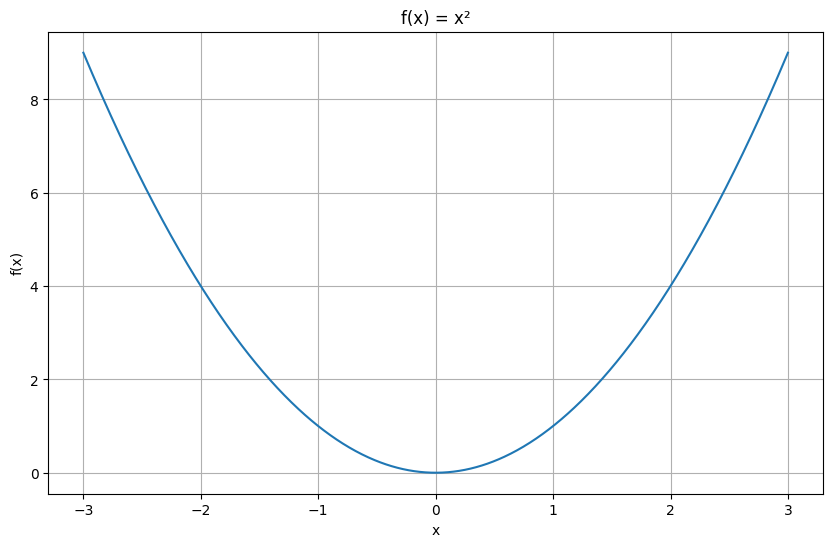

In [3]:
# Define a simple function and its analytical derivative
def f(x):
    return x**2  # f(x) = x^2

def df_analytical(x):
    return 2*x  # f'(x) = 2x

# Plot the function
plot_function_1d(f, -3, 3, title="f(x) = x²")

In [4]:
# Compute the derivative using forward difference at x = 1
x0 = 1.0
h_values = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001]

print("Forward Difference Approximation of f'(1) where f(x) = x²:")
print("Analytical value: f'(1) =", df_analytical(x0))
print("\nNumerical approximations with different step sizes:")
print(f"{'h':<10} {'Approximation':<20} {'Error':<15}")
print("-" * 45)

for h in h_values:
    approx = finite_difference(f, x0, h)
    error = abs(approx - df_analytical(x0))
    print(f"{h:<10.8f} {approx:<20.14f} {error:<15.14f}")

Forward Difference Approximation of f'(1) where f(x) = x²:
Analytical value: f'(1) = 2.0

Numerical approximations with different step sizes:
h          Approximation        Error          
---------------------------------------------
1.00000000 3.00000000000000     1.00000000000000
0.10000000 2.10000000000000     0.10000000000000
0.01000000 2.01000000000000     0.01000000000000
0.00100000 2.00099999999970     0.00099999999970
0.00010000 2.00009999999917     0.00009999999917
0.00001000 2.00001000001393     0.00001000001393
0.00000100 2.00000099992437     0.00000099992437


**Observations**: 

- As we decrease the step size `h`, the approximation initially gets more accurate
- However, when `h` becomes too small (around 10^-8 or smaller), numerical errors due to floating-point precision start to dominate, making the approximation worse
- This demonstrates the trade-off in numerical differentiation: we need a small enough `h` for accuracy, but not so small that floating-point errors take over

### 2.2 Central Difference Method

The central difference method provides a more accurate approximation:

$$f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}$$

Let's compare it with the forward difference method:

In [5]:
print("Comparing Forward and Central Difference at x = 1:")
print(f"{'h':<10} {'Forward Diff':<20} {'Central Diff':<20} {'Forward Error':<15} {'Central Error':<15}")
print("-" * 80)

for h in h_values:
    forward_approx = finite_difference(f, x0, h)
    central_approx = central_difference(f, x0, h)
    forward_error = abs(forward_approx - df_analytical(x0))
    central_error = abs(central_approx - df_analytical(x0))
    print(f"{h:<10.8f} {forward_approx:<20.14f} {central_approx:<20.14f} {forward_error:<15.14f} {central_error:<15.14f}")

Comparing Forward and Central Difference at x = 1:
h          Forward Diff         Central Diff         Forward Error   Central Error  
--------------------------------------------------------------------------------
1.00000000 3.00000000000000     2.00000000000000     1.00000000000000 0.00000000000000
0.10000000 2.10000000000000     2.00000000000000     0.10000000000000 0.00000000000000
0.01000000 2.01000000000000     2.00000000000000     0.01000000000000 0.00000000000000
0.00100000 2.00099999999970     1.99999999999984     0.00099999999970 0.00000000000016
0.00010000 2.00009999999917     1.99999999999922     0.00009999999917 0.00000000000078
0.00001000 2.00001000001393     2.00000000000200     0.00001000001393 0.00000000000200
0.00000100 2.00000099992437     2.00000000000200     0.00000099992437 0.00000000000200


**Observations**:

- The central difference method is generally more accurate than the forward difference method for the same step size
- It's more symmetric and has a higher order of accuracy (O(h²) vs O(h))
- It still suffers from numerical issues at very small step sizes

### 2.3 Visualizing Numerical Derivatives

Let's visualize the numerical derivatives compared to the analytical derivative for our function.

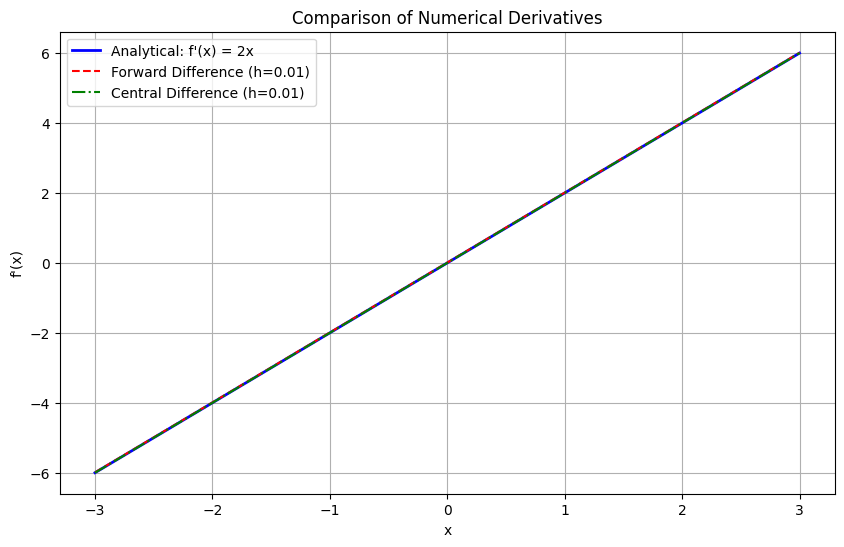

In [6]:
# Create a range of x values
x_values = np.linspace(-3, 3, 100)

# Compute analytical derivatives
analytical_derivatives = np.array([df_analytical(x) for x in x_values])

# Compute numerical derivatives with a moderate step size
h = 0.01
forward_derivatives = np.array([finite_difference(f, x, h) for x in x_values])
central_derivatives = np.array([central_difference(f, x, h) for x in x_values])

# Plot the derivatives
plt.figure(figsize=(10, 6))
plt.plot(x_values, analytical_derivatives, 'b-', linewidth=2, label='Analytical: f\'(x) = 2x')
plt.plot(x_values, forward_derivatives, 'r--', label=f'Forward Difference (h={h})')
plt.plot(x_values, central_derivatives, 'g-.', label=f'Central Difference (h={h})')
plt.title('Comparison of Numerical Derivatives')
plt.xlabel('x')
plt.ylabel('f\'(x)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Second Derivatives

The second derivative measures the rate of change of the first derivative. It tells us about the curvature of the function. 

One way to approximate it numerically is:

$$f''(x) \approx \frac{f(x+h) - 2f(x) + f(x-h)}{h^2}$$

Let's see how this works for our function:

In [7]:
# Analytical second derivative of f(x) = x^2
def d2f_analytical(x):
    return 2  # f''(x) = 2

# Compute second derivatives
x0 = 1.0
h_values = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]

print("Second Derivative Approximation of f''(1) where f(x) = x²:")
print("Analytical value: f''(1) =", d2f_analytical(x0))
print("\nNumerical approximations with different step sizes:")
print(f"{'h':<10} {'Approximation':<20} {'Error':<15}")
print("-" * 45)

for h in h_values:
    approx = second_derivative(f, x0, h)
    error = abs(approx - d2f_analytical(x0))
    print(f"{h:<10.8f} {approx:<20.14f} {error:<15.14f}")

Second Derivative Approximation of f''(1) where f(x) = x²:
Analytical value: f''(1) = 2

Numerical approximations with different step sizes:
h          Approximation        Error          
---------------------------------------------
1.00000000 2.00000000000000     0.00000000000000
0.10000000 2.00000000000002     0.00000000000002
0.01000000 1.99999999999978     0.00000000000022
0.00100000 1.99999999972444     0.00000000027556
0.00010000 1.99999999894729     0.00000000105271
0.00001000 2.00000238592679     0.00000238592679


## 4. Exploring More Complex Functions

Let's try our differentiation techniques on more complex functions to see how they perform.

In [15]:
# Define some more interesting functions and their derivatives
def sin_function(x):
    return np.sin(x)

def sin_derivative(x):
    return np.cos(x)

def exp_function(x):
    return np.exp(x)

def exp_derivative(x):
    return np.exp(x)

def complex_function(x):
    return x**3 - 2*x**2 + 2*x - 1

def complex_derivative(x):
    return 3*x**2 - 4*x + 2

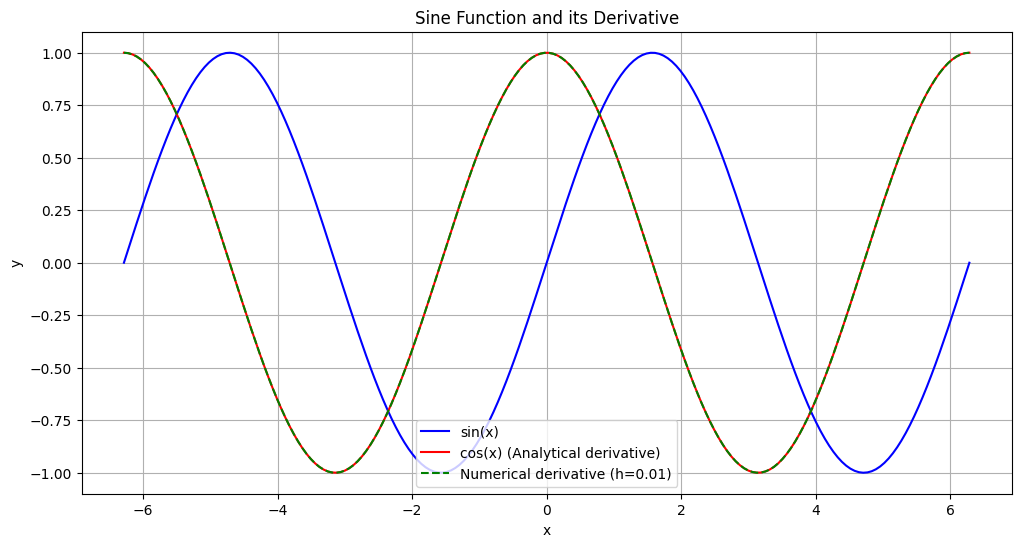

In [16]:
# Visualize sine function and its derivative
x_values = np.linspace(-2*np.pi, 2*np.pi, 200)
sin_values = np.array([sin_function(x) for x in x_values])
cos_values = np.array([sin_derivative(x) for x in x_values])
sin_numerical = np.array([central_difference(sin_function, x, 0.01) for x in x_values])

plt.figure(figsize=(12, 6))
plt.plot(x_values, sin_values, 'b-', label='sin(x)')
plt.plot(x_values, cos_values, 'r-', label='cos(x) (Analytical derivative)')
plt.plot(x_values, sin_numerical, 'g--', label='Numerical derivative (h=0.01)')
plt.title('Sine Function and its Derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

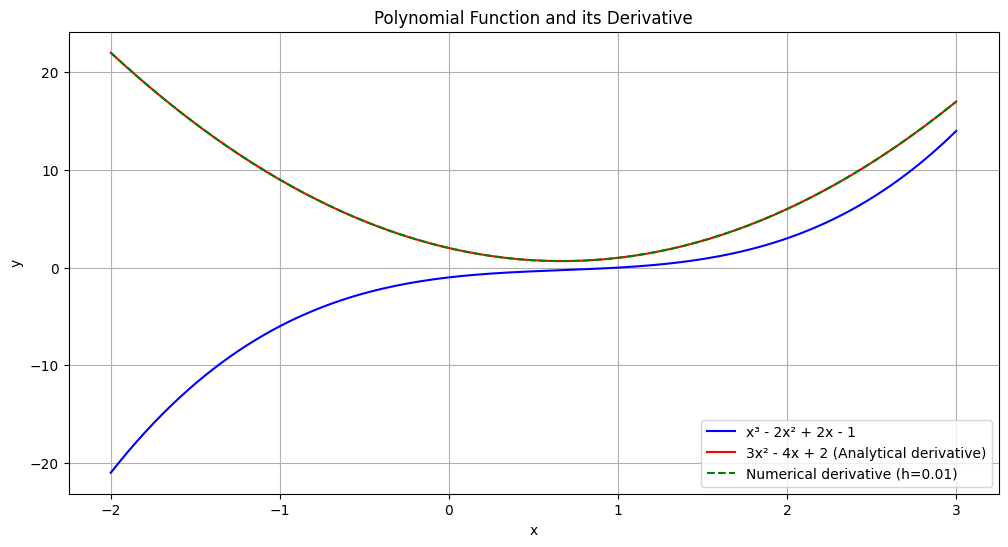

In [10]:
# Visualize polynomial function and its derivative
x_values = np.linspace(-2, 3, 200)
poly_values = np.array([complex_function(x) for x in x_values])
poly_deriv_values = np.array([complex_derivative(x) for x in x_values])
poly_numerical = np.array([central_difference(complex_function, x, 0.01) for x in x_values])

plt.figure(figsize=(12, 6))
plt.plot(x_values, poly_values, 'b-', label='x³ - 2x² + 2x - 1')
plt.plot(x_values, poly_deriv_values, 'r-', label='3x² - 4x + 2 (Analytical derivative)')
plt.plot(x_values, poly_numerical, 'g--', label='Numerical derivative (h=0.01)')
plt.title('Polynomial Function and its Derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## 5. Understanding the Error in Numerical Differentiation

Let's look at how the error in numerical differentiation varies with the step size `h`. We'll plot the error as a function of the step size to find the optimal range.

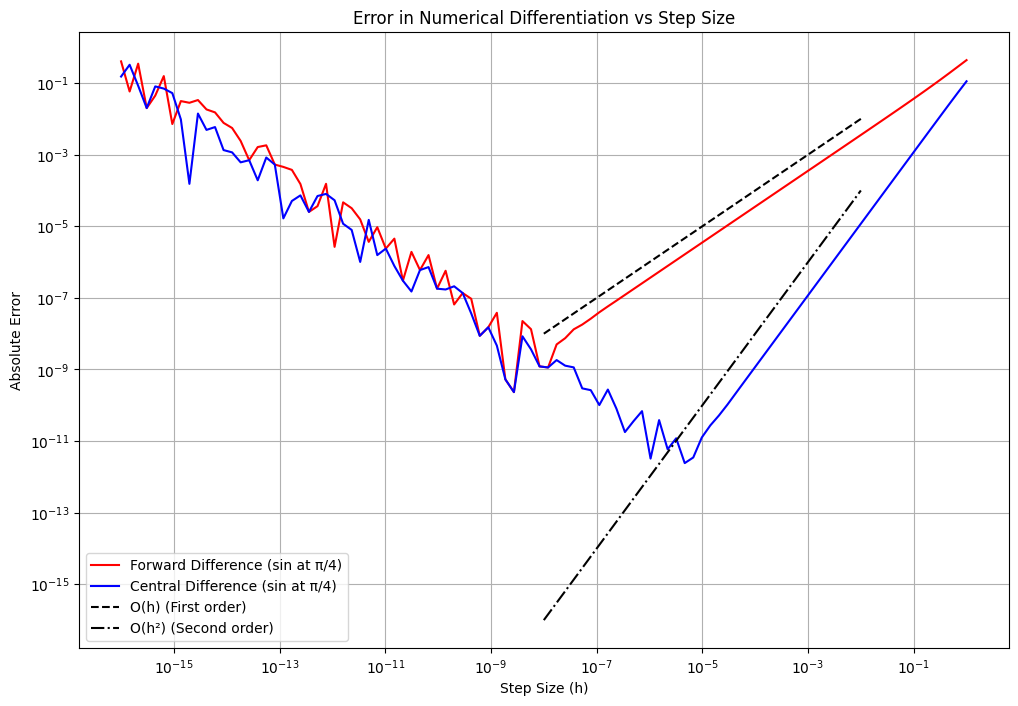

In [11]:
# Function to compute error for a given method, function, and step size
def compute_error(diff_method, func, dfunc, x0, h):
    numerical = diff_method(func, x0, h)
    analytical = dfunc(x0)
    return abs(numerical - analytical)

# Range of step sizes to test
h_values = np.logspace(-16, 0, 100)  # From 10^-16 to 10^0

# Compute errors for different methods and functions
forward_errors_sin = [compute_error(finite_difference, sin_function, sin_derivative, np.pi/4, h) for h in h_values]
central_errors_sin = [compute_error(central_difference, sin_function, sin_derivative, np.pi/4, h) for h in h_values]

# Plot errors vs step size
plt.figure(figsize=(12, 8))
plt.loglog(h_values, forward_errors_sin, 'r-', label='Forward Difference (sin at π/4)')
plt.loglog(h_values, central_errors_sin, 'b-', label='Central Difference (sin at π/4)')

# Add reference slopes to show error order
h_ref = np.logspace(-8, -2, 10)
plt.loglog(h_ref, h_ref, 'k--', label='O(h) (First order)')
plt.loglog(h_ref, h_ref**2, 'k-.', label='O(h²) (Second order)')

plt.title('Error in Numerical Differentiation vs Step Size')
plt.xlabel('Step Size (h)')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

**Observations**:

1. The error generally follows a U-shape when plotted on a log-log scale
2. For large step sizes, the approximation error dominates (this follows the expected order: O(h) for forward difference, O(h²) for central difference)
3. For very small step sizes, the floating-point precision error dominates
4. There's an optimal range of step sizes where the error is minimized (usually between 10^-8 and 10^-4)

## 6. Application: Finding Critical Points

One important application of derivatives is finding critical points of functions (where the derivative equals zero). These could be minima, maxima, or inflection points.

In [12]:
def find_critical_points(f, df, x_min, x_max, num_points=1000, tolerance=1e-6):
    """Find points where the derivative is approximately zero."""
    x_values = np.linspace(x_min, x_max, num_points)
    derivative_values = np.array([df(x) for x in x_values])
    
    # Find where the derivative changes sign
    sign_changes = np.where(np.diff(np.signbit(derivative_values)))[0]
    critical_points = []
    
    # Refine the locations of zero crossings
    for idx in sign_changes:
        x1, x2 = x_values[idx], x_values[idx + 1]
        # Simple bisection to refine the root
        while abs(x2 - x1) > tolerance:
            mid = (x1 + x2) / 2
            if df(mid) * df(x1) <= 0:
                x2 = mid
            else:
                x1 = mid
        critical_points.append((x1 + x2) / 2)
    
    return critical_points

# Let's test with a function that has multiple critical points
def test_function(x):
    return x**4 - 4*x**2 + 2  # This has minima at x = ±√2 and a local maximum at x = 0

def test_derivative(x):
    return 4*x**3 - 8*x  # Derivative is 4x³ - 8x

# Find the critical points
critical_points = find_critical_points(test_function, test_derivative, -3, 3)
print("Detected critical points:", critical_points)

# Verify with analytical values
analytical_points = [0, -np.sqrt(2), np.sqrt(2)]
print("Analytical critical points:", analytical_points)

Detected critical points: [-1.4142138965137008, -3.665775150149932e-07, 1.4142138965137012]
Analytical critical points: [0, -1.4142135623730951, 1.4142135623730951]


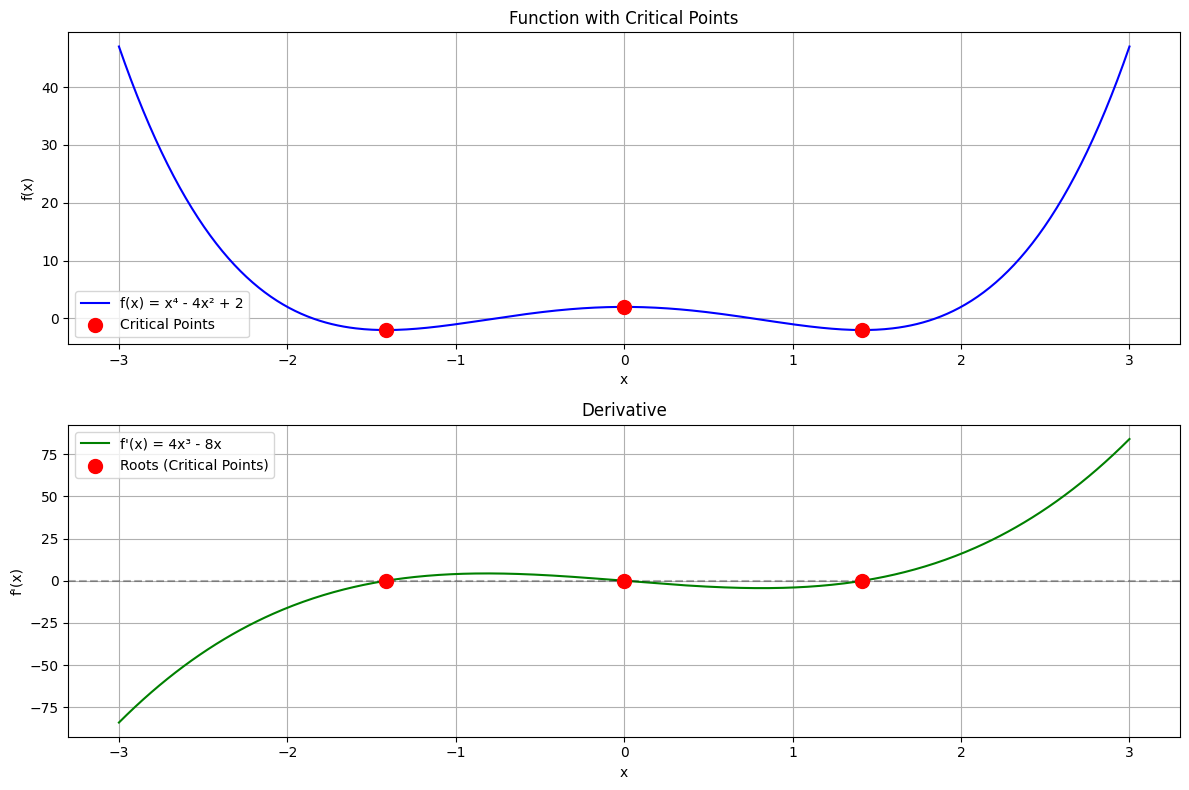

In [13]:
# Visualize the function and its critical points
x_values = np.linspace(-3, 3, 500)
y_values = np.array([test_function(x) for x in x_values])
y_deriv = np.array([test_derivative(x) for x in x_values])
y_crit = np.array([test_function(x) for x in critical_points])

plt.figure(figsize=(12, 8))

# Plot the function
plt.subplot(2, 1, 1)
plt.plot(x_values, y_values, 'b-', label='f(x) = x⁴ - 4x² + 2')
plt.scatter(critical_points, y_crit, color='red', s=100, zorder=5, label='Critical Points')
plt.title('Function with Critical Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()

# Plot the derivative
plt.subplot(2, 1, 2)
plt.plot(x_values, y_deriv, 'g-', label="f'(x) = 4x³ - 8x")
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.scatter(critical_points, np.zeros_like(critical_points), color='red', s=100, zorder=5, label='Roots (Critical Points)')
plt.title('Derivative')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 7. Using Only Numerical Differentiation

In many real-world scenarios, we don't have access to the analytical derivative of a function. Let's try to find critical points using only our numerical differentiation functions.

In [14]:
def find_critical_points_numerical(f, x_min, x_max, num_points=1000, h=1e-5, tolerance=1e-6):
    """Find critical points using numerical differentiation."""
    x_values = np.linspace(x_min, x_max, num_points)
    derivative_values = np.array([central_difference(f, x, h) for x in x_values])
    
    # Find where the derivative changes sign
    sign_changes = np.where(np.diff(np.signbit(derivative_values)))[0]
    critical_points = []
    
    # Refine the locations of zero crossings
    for idx in sign_changes:
        x1, x2 = x_values[idx], x_values[idx + 1]
        # Simple bisection to refine the root
        while abs(x2 - x1) > tolerance:
            mid = (x1 + x2) / 2
            if central_difference(f, mid, h) * central_difference(f, x1, h) <= 0:
                x2 = mid
            else:
                x1 = mid
        critical_points.append((x1 + x2) / 2)
    
    return critical_points

# Let's try our numerical approach
numerical_critical_points = find_critical_points_numerical(test_function, -3, 3)
print("Critical points using numerical differentiation:", numerical_critical_points)
print("Analytical critical points:", analytical_points)

Critical points using numerical differentiation: [-1.4142138965137008, -3.665775150149932e-07, 1.4142138965137012]
Analytical critical points: [0, -1.4142135623730951, 1.4142135623730951]


## 8. Conclusion

In this notebook, we've explored numerical differentiation techniques and their applications. Key takeaways include:

1. **Numerical Differentiation Methods**:
   - Forward difference: simple but less accurate
   - Central difference: more accurate but requires function evaluation at two points
   - Different methods have different accuracy orders (O(h) vs O(h²))

2. **Step Size Selection**:
   - Too large: high approximation error
   - Too small: dominated by floating-point errors
   - Optimal range typically between 10^-8 and 10^-4

3. **Applications**:
   - Finding critical points (minima, maxima)
   - Curve analysis
   - This will be essential for optimization algorithms like gradient descent

In the next notebook, we'll explore gradient descent and optimization techniques that build upon these differentiation concepts.